# Healthcare Readmission Analysis

This project analyzes hospital readmission data to identify patterns and
risk factors associated with patients returning to the hospital.

The goal is to understand which characteristics are linked to higher
readmission rates and provide insights that can support better healthcare decisions.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('Data/hospital_readmissions_30k.csv')
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [12]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000


In [16]:
df.isnull().sum()


patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

No significant missing values were found n the dataset.

In [19]:
df.dtypes

patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
dtype: object

In [21]:
df['diabetes'] = df['diabetes'].map({'Yes':True, 'No':False})
df["hypertension"] = df["hypertension"].map({"Yes": True, "No": False})

In [25]:
df.duplicated().sum()

0

## Readmission Rate

Text(0.5, 1.0, 'Readmission Rate')

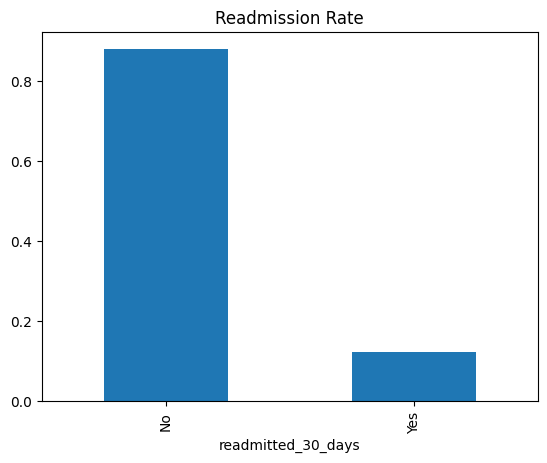

In [29]:
readmission_rate = df['readmitted_30_days'].value_counts(normalize=True)

readmission_rate.plot(kind='bar')
plt.title('Readmission Rate')

Most patients are not readmitted within 30 days, but a noticeable portion
returns to the hospital. Although the readmission rate is relatively low,
it still represents a meaningful group of patients and may indicate
underlying issues in treatment, discharge planning, or patient conditions.

## Age vs Readmission

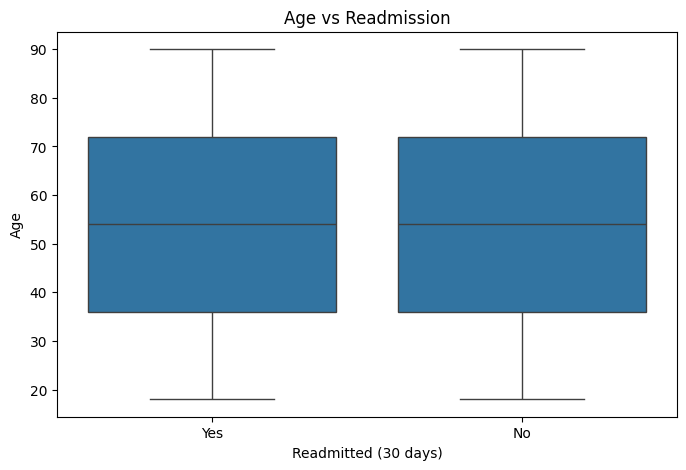

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='readmitted_30_days', y='age')

plt.title('Age vs Readmission')
plt.xlabel('Readmitted (30 days)')
plt.ylabel('Age')

plt.show()
            

The age distribution is very similar between readmitted and non-readmitted
patients. This result indicates that other factors, such as medical conditions or treatment
variables, may play a more significant role in readmission than age alone.

## Length of Stay

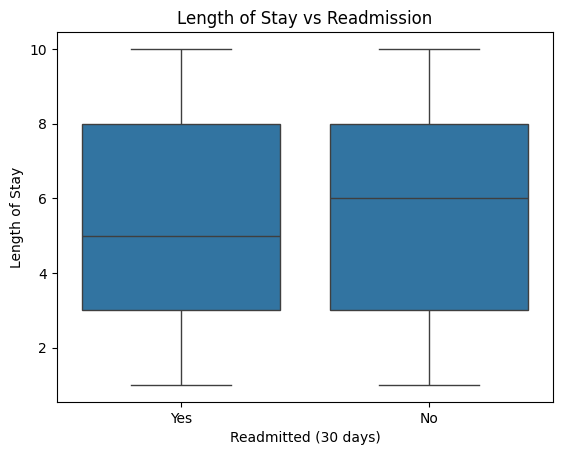

In [50]:
sns.boxplot(data=df, x="readmitted_30_days", y="length_of_stay")
plt.title("Length of Stay vs Readmission")
plt.xlabel('Readmitted (30 days)')
plt.ylabel('Length of Stay')

plt.show()

The distribution of length of stay is very similar between readmitted and
non-readmitted patients. This result indicates that other variables, such as medical conditions or
treatment complexity, may have a greater influence on readmission outcomes.

## Medication Count

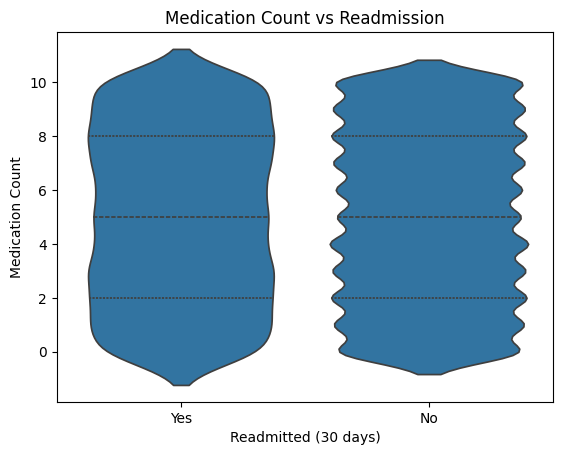

In [67]:
sns.violinplot(
    data=df,
    x="readmitted_30_days",
    y="medication_count",
    inner="quartile"
)

plt.title("Medication Count vs Readmission")
plt.xlabel("Readmitted (30 days)")
plt.ylabel("Medication Count")

plt.show()

In [69]:
df.groupby("readmitted_30_days")["medication_count"].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted_30_days,,,,,,,,
No,26326.0,5.012383,3.165291,0.0,2.0,5.0,8.0,10.0
Yes,3674.0,5.011432,3.174631,0.0,2.0,5.0,8.0,10.0


In [71]:
df.groupby("readmitted_30_days")["medication_count"].mean()

readmitted_30_days
No     5.012383
Yes    5.011432
Name: medication_count, dtype: float64

The distribution of medication count is largely similar between groups,
although slight variations can be observed. This suggests that medication
count alone is not a strong driver of readmission, but may have a minor
influence when combined with other factors.

## Conditions (Diabetes / Hypertension)

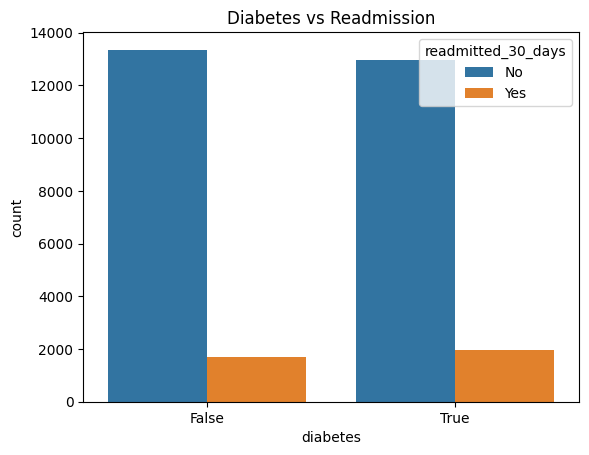

In [61]:
sns.countplot(data=df, x="diabetes", hue="readmitted_30_days")
plt.title("Diabetes vs Readmission")
plt.show()

In [78]:
pd.crosstab(df["diabetes"], df["readmitted_30_days"], normalize="index")

readmitted_30_days,No,Yes
diabetes,,
False,0.887184,0.112816
True,0.867817,0.132183


## Diabetes vs Readmission

Patients with diabetes show a slightly higher readmission rate compared to
those without the condition. While the difference is not substantial, it
suggests that diabetes may be a contributing factor to readmission when
combined with other variables.

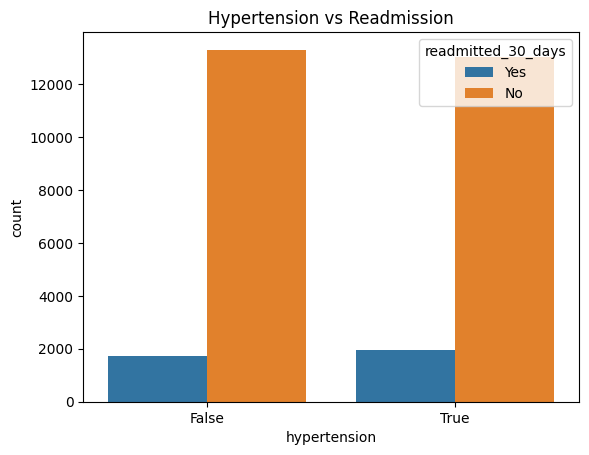

In [76]:
sns.countplot(data=df, x="hypertension", hue="readmitted_30_days")
plt.title("Hypertension vs Readmission")
plt.show()

In [82]:
pd.crosstab(df["hypertension"], df["readmitted_30_days"], normalize="index")

readmitted_30_days,No,Yes
hypertension,,
False,0.884902,0.115098
True,0.870143,0.129857


## Hypertension vs Readmission

Patients with hypertension also present a slightly higher readmission rate.
Similar to diabetes, the effect is not strong on its own, indicating that
readmission is likely influenced by a combination of factors rather than a
single condition.

## Key Insight

No single variable strongly explains hospital readmission in this dataset.
Instead, the results suggest that readmission is influenced by a combination
of factors, including patient conditions and treatment complexity.